                                                                    MLOps: Everything You Need to Know                                         

# MLOps: Everything You Need to Know

MLOps (Machine Learning Operations) is essential for efficiently deploying, managing and scaling machine learning models in production. Traditional ML development often faces challenges that MLOps solves:

* **Lack of Team Collaboration:** When teams work separately without talking to each other it causes confusion, delays and mistakes
* **Manual Deployment:** Manually deploying models takes a lot of time and can cause mistakes
* **Poor Version Tracking:** It’s difficult to track which version of the model is in use or what changes have been made.
* **No Ongoing Monitoring:** Once a model is live there’s no system in place to monitor its performance regularly.
* **Resource Management Issues:** As the project gets bigger it becomes harder to handle computing power and storage without using automation.

## MLOps Workflow

MLOps workflow helps teams to manage machine learning projects smoothly and automatically. Here's how it works:

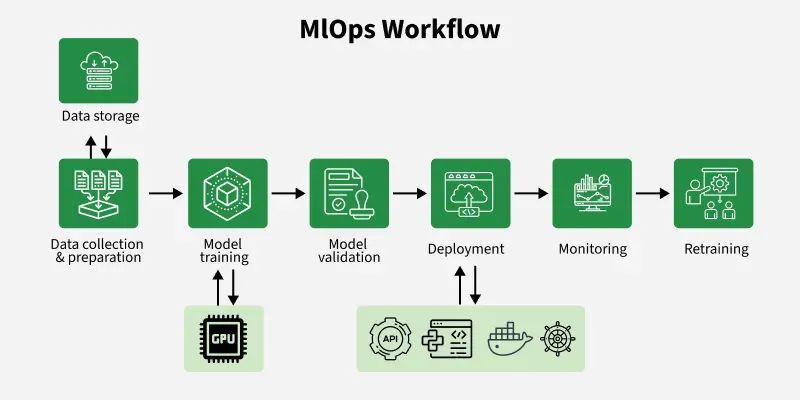

## How to Implement MLOps in an Organization

* **1. Evaluate Current Workflows:** Start by understanding your existing ML processes. Identify manual steps, bottlenecks or areas where models fail in production. This gives a baseline for improvement and helps prioritize efforts.

* **2. Define Goals and Success Metrics:** Decide what you want to achieve with MLOps. Goals could include faster model deployment, more accurate predictions or better resource usage. Define measurable KPIs to track progress.

* **3. Form a Cross-Functional Team:** Bring together data scientists, ML engineers, DevOps and business stakeholders. Collaboration ensures all aspects of ML—data, model development, deployment and monitoring—are covered.

* **4. Version Control and Experiment Tracking:** Track code, datasets and model experiments using tools like Git, MLflow or Weights & Biases. This ensures reproducibility and helps teams know what works and why.

* **5. Automate Data Pipelines:** Create automated workflows for collecting, cleaning and preparing data. Tools like Kubeflow or Apache Airflow can help orchestrate these pipelines efficiently.

* **6. Containerize ML Models:** Package models in containers (e.g., Docker) to ensure they run consistently across environments. Containerization also makes deployment and scaling much simpler.

* **7. Implement CI/CD for ML:** Set up Continuous Integration and Continuous Deployment pipelines for models. Automate testing, validation and deployment so new versions can go live quickly and safely.

* **8. Monitor Models in Production:** Track metrics like accuracy, latency and prediction quality. Detect data or concept drift early and identify any issues before they impact users.

* **9. Enable Automated Retraining:** Set up pipelines that automatically retrain models when performance drops or when new data arrives. This keeps models up-to-date and accurate over time.

* **10. Ensure Security and Compliance:** Protect sensitive data and comply with regulations. Use access controls, audit logs and privacy-preserving methods such as differential privacy or federated learning.


## MLOps Components and Life Cycle

MLOps plays a important role in managing and scaling the deployment of machine learning models. It integrates machine learning workflows with practices where models are not only developed but also efficiently deployed and maintained. It fills the gap between model development and production.

## MLOps Life Cycle

The MLOps life cycle involves several steps that guide the process from understanding a problem to deploying and monitoring a model.

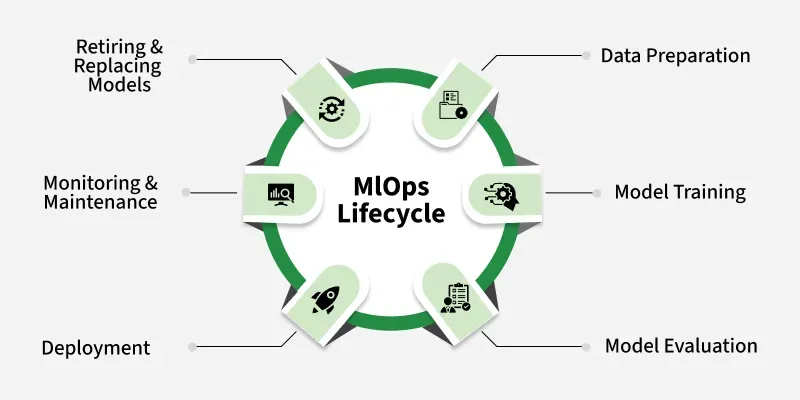

## Components of MLOps

MLOps consists of several key components that work together to streamline the machine learning lifecycle:
* **Data Management:** This component focuses on collecting, storing and processing data. It ensures that data is clean, organized and accessible for model training and evaluation.
* **Model Development:** This is where data scientists build and train machine learning models. It involves selecting algorithms, tuning hyperparameters and validating model performance.
* **Model Deployment:** This component handles the process of taking a trained model and making it available for use in production. It involves packaging the model, setting up APIs and ensuring it can handle real-world traffic.
* **Model Monitoring:** Once a model is deployed, this component tracks its performance in production. It monitors metrics like accuracy, latency and resource usage to ensure the model continues to perform well and identifies any issues that may arise.
* **Model Retraining:** This component automates the process of retraining models when performance degrades or when new data becomes available. It ensures that models remain accurate and up-to-date over time.

## Best Practices for MLOps Lifecycle Management

* **Automate Repetitive Tasks:** Use automation for training, testing and deploying models. This saves time and reduces human error.
* **Track Everything:** Always track code changes, data versions, model performance and experiments. This helps with debugging and improves team collaboration.
* **Write Modular Code:** Split your code into smaller, reusable parts. This makes maintenance easier and prevents issues when updates are made.
* **Test Before You Deploy:** Make sure your model performs well on test data before putting it into production. Automate testing to save time.
* **Monitor Continuously:** Set up real-time monitoring tools. Watch for drops in performance or signs of "model drift."
* **Plan for Regular Retraining:** Data keeps changing. Schedule retraining based on time intervals or when model performance drops.




## MLOps Pipeline

An MLOps pipeline is a step-by-step process used to manage and run machine learning (ML) projects more efficiently. MLOps helps connect the work of data scientists and software teams. It makes sure that machine learning models can be built, tested and used in real-world systems without problems. The pipeline usually includes these main stages:

* Data Collection and Preparation
* Model Training and Testing
* Model Deployment
* Model Monitoring
* Model Updates and Improvements

Each step is designed to run automatically and repeat whenever needed.

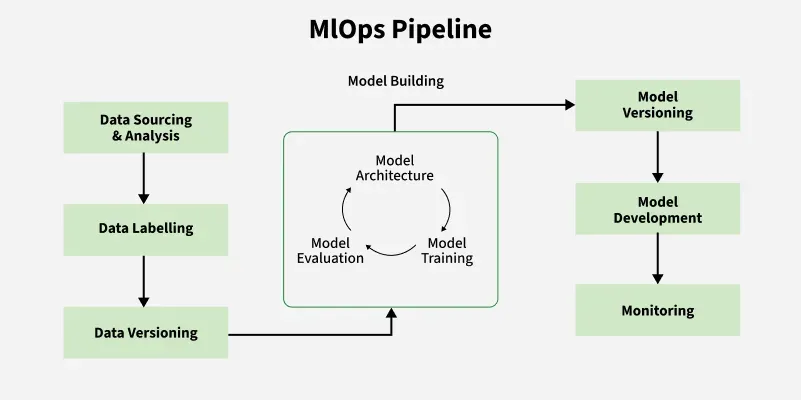

## Implementation of MLOps Pipeline

Implementing an MLOps pipeline means creating a system where machine learning models can be built, tested, deployed and monitored smoothly. Below is a step-by-step guide to build this pipeline using Python, Docker and Kubernetes.

## Step 1: Data Ingestion and Preprocessing

Airflow is a tool for orchestrating data pipelines. Here's an example DAG (Directed Acyclic Graph) that automates data ingestion and preprocessing:

In [1]:
# Step 1: Data Ingestion and Preprocessing

from airflow import DAG
from airflow.operators.python_operator import PythonOperator
from datetime import datetime
import pandas as pd


def preprocess_data():
    df = pd.read_csv('data/raw_data.csv')
    df.fillna(0, inplace=True)
    df['new_feature'] = df['feature_1'] * df['feature_2']
    df.to_csv('data/preprocessed_data.csv', index=False)


default_args = {
    'owner': 'airflow',
    'start_date': datetime(2023, 1, 1),
    'retries': 1,
}

dag = DAG(
    'data_preprocessing_pipeline',
    default_args=default_args,
    schedule_interval='@daily',
)

preprocess_task = PythonOperator(
    task_id='preprocess_data',
    python_callable=preprocess_data,
    dag=dag,
)

preprocess_task

ModuleNotFoundError: No module named 'airflow'

## Step 2: Model Training with MLflow for Experiment Tracking

MLflow helps track experiments, log parameters and store models. Below is an example of training a model using scikit-learn and logging it with MLflow:

In [ ]:
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv('data/preprocessed_data.csv')
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
with mlflow.start_run():

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(model, "random_forest_model")

## Step 3: Model Deployment

Once the model is trained it can be deployed as a REST API using Flask and containerized with Docker.

Flask API Code (app.py):

In [ ]:
from flask import Flask, request, jsonify
import joblib
import pandas as pd

app = Flask(__name__)

model = joblib.load('model/random_forest_model.pkl')


@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    df = pd.DataFrame([data])
    prediction = model.predict(df)
    return jsonify({'prediction': int(prediction[0])})


if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)

Dockerfile:

In [ ]:
# Base image
FROM python:3.8-slim

# Set working directory
WORKDIR /app

# Install dependencies
COPY requirements.txt requirements.txt
RUN pip install -r requirements.txt

# Copy application code
COPY . .

# Expose port
EXPOSE 5000

# Run the app
CMD ["python", "app.py"]

Build and run the Docker container:

docker build -t ml-model-api .

docker run -p 5000:5000 ml-model-api

## Step 4: Monitoring Model Performance with Prometheus and Grafana

Prometheus collects metrics and Grafana visualizes them. Below is an example of setting up monitoring for model accuracy.

Prometheus Configuration (prometheus.yml):

In [ ]:
global:
  scrape_interval: 15s

scrape_configs:
  - job_name: 'ml_model'
    static_configs:
      - targets: ['localhost:8000']

Export Metrics with Flask:

In [ ]:
from flask import Flask
from prometheus_client import start_http_server, Counter

app = Flask(__name__)
REQUESTS = Counter('http_requests_total', 'Total HTTP Requests')


@app.route('/')
def home():
    REQUESTS.inc()
    return "Hello, World!"


if __name__ == '__main__':
    start_http_server(8000)
    app.run(port=5000)

Run Prometheus and Grafana locally using Docker Compose:

In [ ]:
version: '3'
services:
  prometheus:
    image: prom/prometheus
    volumes:
      - ./prometheus.yml:/etc/prometheus/prometheus.yml
    ports:
      - "9090:9090"
  grafana:
    image: grafana/grafana
    ports:
      - "3000:3000"

Start the services:

docker-compose up



## Step 5: Feedback and Iteration

A/B testing compares two versions of a model. Below is an example of serving two models simultaneously using FastAPI.

In [ ]:
from fastapi import FastAPI, Query
import joblib
import pandas as pd

app = FastAPI()

model_a = joblib.load('model/model_a.pkl')
model_b = joblib.load('model/model_b.pkl')


@app.post("/predict/")
async def predict(features: dict, model_version: str = Query(..., enum=["A", "B"])):
    df = pd.DataFrame([features])
    if model_version == "A":
        prediction = model_a.predict(df)
    elif model_version == "B":
        prediction = model_b.predict(df)
    return {"model_version": model_version, "prediction": int(prediction[0])}

* **Data Pipeline :** Use Airflow to automate data ingestion and preprocessing.
* **Model Training :** Use MLflow to track experiments and log models.
* **Model Deployment :** Containerize the model with Docker and deploy it as a REST API.
* **Monitoring :** Use Prometheus and Grafana to monitor model performance in production.
* **Iteration :** Implement A/B testing and feedback loops to refine the model.

## Best Practices for Effective MLOps

* **Monitor Load:** Track response time, throughput and errors to ensure models scale under heavy traffic (e.g., peak e-commerce demand).
* **Detect Drift:** Watch for data changes that reduce accuracy and retrain models regularly to stay reliable.
* **Ensure Security:** Protect sensitive data with encryption, access control and audits for compliance.